In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 
from auton_survival import reporting
import matplotlib.pyplot as plt
from metrics import treatment_effect

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets_retrospective import load_sprint_dataset
outcomes, features, intervention, cat_feats, num_feats = load_sprint_dataset(location='datasets/', outcome='PRIMARY')

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:994: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1174: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'EP_CHD': outcomedt = 'DYCHD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1175: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'CANCER': outcomedt = 'DYCANC'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1176: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'GIBLEED': outcomedt = 'DYGIBLD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospe

(9361, 27)
(6646, 2)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intervention[intervention == 1.0] = 'SBP target <120mm Hg'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:119: SettingWithCopyWar

In [4]:
features.Baseline_Weight_KG

S00007     89.550
S00010        NaN
S00022     63.225
S00038    114.750
S00045        NaN
           ...   
S99969        NaN
S99974        NaN
S99983     64.575
S99992    105.300
S99997     74.520
Name: Baseline_Weight_KG, Length: 9361, dtype: float64

In [4]:
# Preprocess feature data
from preprocessing import Preprocessor
features_prep = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [5]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
# vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [6]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features_prep, outcomes.time, outcomes.event, intervention=='SBP target <120mm Hg', val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:43<00:00,  2.31it/s]


In [7]:
zeta_probs = model.predict_latent_phi(features_prep)
zeta =  np.argmax(zeta_probs, axis=1)

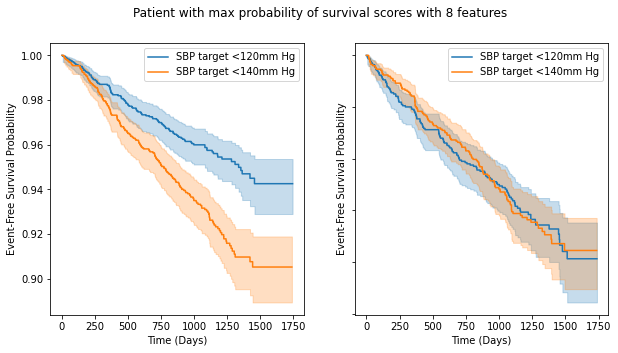

In [8]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores with 8 features')
reporting.plot_kaplanmeier(outcomes[zeta == 0], intervention[zeta == 0], ax=ax1)
reporting.plot_kaplanmeier(outcomes[zeta == 1], intervention[zeta == 1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['SBP target <120mm Hg', 'SBP target <140mm Hg'], loc="upper right")
plt.show()